## eGRID Emissions Final Project
========================
Baseline modeling pipeline for EPA eGRID 2023 Plant-Level CO2 Intensity Prediction.

Pipeline stages:
    1. Linear Regression          -- interpretable baseline
    2. 1-Hidden-Layer ReLU MLP    -- minimal neural network baseline
    3. Deep MLP (residual-ready)  -- bridge to full deep learning

Target variable  : PLCO2RTA  (plant annual CO2 total output emission rate, lb/MWh)
Secondary targets: PLCO2ERTA (CO2 equivalent, lb/MWh), PLCO2IQA (input rate, lb/MMBtu)

Author : Michael Paul

In [3]:
# ── Imports ────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [4]:
# ── Config ─────────────────────────────────────────────────────────────────────
EGRID_PATH   = "/content/egrid 2023 data.xlsx"   # update path if needed
SHEET        = "PLNT23"
TARGET       = "PLCO2RTA"             # lb CO2 / MWh (output rate)
RANDOM_SEED  = 42
TEST_SIZE    = 0.20
VAL_SIZE     = 0.10                   # fraction of train set used for validation
BATCH_SIZE   = 256
EPOCHS_SMALL = 50                     # 1-hidden-layer model
EPOCHS_DEEP  = 100                    # deep MLP
LR           = 1e-3

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [5]:
# ── 1. Load & Inspect Data ─────────────────────────────────────────────────────
print("=" * 65)
print("STEP 1 — Load eGRID PLNT23")
print("=" * 65)

df_raw = pd.read_excel(EGRID_PATH, sheet_name=SHEET, header=1)
print(f"Raw shape : {df_raw.shape}")
print(f"Columns   : {list(df_raw.columns[:10])} ...")

STEP 1 — Load eGRID PLNT23
Raw shape : (12612, 150)
Columns   : ['SEQPLT23', 'YEAR', 'PSTATABB', 'PNAME', 'ORISPL', 'OPRNAME', 'OPRCODE', 'UTLSRVNM', 'UTLSRVID', 'SECTOR'] ...


In [7]:
# ── 2. Feature Selection ───────────────────────────────────────────────────────
# Operational continuous features
continuous_features = [
    "CAPFAC",       # capacity factor
    "NAMEPCAP",     # nameplate capacity (MW)
    "NUMUNT",       # number of units
    "NUMGEN",       # number of generators
    "PLNGENAN",     # net generation (MWh)
    "HTIAN",        # combustion heat input (MMBtu)
    "HTIOZN",       # useful thermal output (CHP)
    "PLCO2AN",      # annual CO2 (short tons)  -- informative but not leaking target
]

# Resource-mix generation columns (MWh by fuel)
gen_cols = [
    "PLGENACL", "PLGENAO2", "PLGENAOG", "PLGENAOL",
    "PLGENAGAS", "PLGENAATH", "PLGENAUNK",
    "PLGENACS",  # coal steam
    "PLGENANUC", "PLGENAHYD", "PLGENABIO",
    "PLGENADFO", "PLGENAWND", "PLGENASUN", "PLGENAOTF",
]

# Categorical features for label encoding
cat_features = [
    "PLFUELCT",    # primary fuel category
    "SUBRGN",      # eGRID subregion
    "NERC",        # NERC region
    "SECTOR",      # plant sector
    "ISORTO",      # ISO/RTO territory
]

# --- FIX: Filter out non-existent columns -------------------------------------
# Print all columns for inspection
print(f"\nAll columns in df_raw: {list(df_raw.columns)}\n")

# Filter features to only include those present in df_raw
existing_columns = df_raw.columns.tolist()
continuous_features = [col for col in continuous_features if col in existing_columns]
gen_cols = [col for col in gen_cols if col in existing_columns]
cat_features = [col for col in cat_features if col in existing_columns]

# Re-create all_features with filtered lists
all_features = continuous_features + gen_cols + cat_features

print(f"Filtered continuous features: {continuous_features}")
print(f"Filtered generation columns: {gen_cols}")
print(f"Filtered categorical features: {cat_features}")
print(f"Total features after filtering: {len(all_features)}\n")
# --------------------------------------------------------------------------------


# Keep rows that have the target
df = df_raw[all_features + [TARGET]].copy()
df = df[df[TARGET].notna() & (df[TARGET] > 0)]   # drop zero/missing targets
print(f"\nAfter target filter: {df.shape}")


All columns in df_raw: ['SEQPLT23', 'YEAR', 'PSTATABB', 'PNAME', 'ORISPL', 'OPRNAME', 'OPRCODE', 'UTLSRVNM', 'UTLSRVID', 'SECTOR', 'BANAME', 'BACODE', 'NERC', 'SUBRGN', 'SRNAME', 'ISORTO', 'FIPSST', 'FIPSCNTY', 'CNTYNAME', 'LAT', 'LON', 'CAPDFLAG', 'NUMUNT', 'NUMGEN', 'PLPRMFL', 'PLFUELCT', 'COALFLAG', 'CAPFAC', 'NAMEPCAP', 'NBFACTOR', 'RMBMFLAG', 'CHPFLAG', 'USETHRMO', 'PWRTOHT', 'ELCALLOC', 'PSFLAG', 'PLHTIAN', 'PLHTIOZ', 'PLHTIANT', 'PLHTIOZT', 'PLNGENAN', 'PLNGENOZ', 'PLNGENNB', 'PLNOXAN', 'PLNOXOZ', 'PLSO2AN', 'PLCO2AN', 'PLCH4AN', 'PLN2OAN', 'PLCO2EQA', 'PLHGAN', 'PLNOXRTA', 'PLNOXRTO', 'PLSO2RTA', 'PLCO2RTA', 'PLCH4RTA', 'PLN2ORTA', 'PLC2ERTA', 'PLHGRTA', 'PLNOXRA', 'PLNOXRO', 'PLSO2RA', 'PLCO2RA', 'PLCH4RA', 'PLN2ORA', 'PLC2ERA', 'PLHGRA', 'PLNOXCRT', 'PLNOXCRO', 'PLSO2CRT', 'PLCO2CRT', 'PLCH4CRT', 'PLN2OCRT', 'PLC2ECRT', 'PLHGCRT', 'UNNOX', 'UNNOXOZ', 'UNSO2', 'UNCO2', 'UNCH4', 'UNN2O', 'UNCO2E', 'UNHG', 'UNHTI', 'UNHTIOZ', 'UNHTIT', 'UNHTIOZT', 'UNNOXSRC', 'UNNOZSRC', 'UNSO2

In [8]:
# ── 3. Preprocessing ───────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("STEP 2 — Preprocessing")
print("=" * 65)

# Label-encode categoricals
le = LabelEncoder()
for col in cat_features:
    df[col] = df[col].fillna("UNKNOWN").astype(str)
    df[col] = le.fit_transform(df[col])

# Fill missing continuous values with median
for col in continuous_features + gen_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

# Log-transform right-skewed generation columns (add 1 to handle zeros)
for col in gen_cols:
    df[col] = np.log1p(df[col].clip(lower=0))

X = df[all_features].values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)

print(f"Feature matrix : {X.shape}")
print(f"Target range   : [{y.min():.1f}, {y.max():.1f}] lb/MWh")

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

# Validation split (from training set)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=RANDOM_SEED
)

# Standardize (fit on training only)
scaler = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

n_features = X_tr_s.shape[1]
print(f"Train / Val / Test : {len(X_tr)} / {len(X_val)} / {len(X_test)}")



STEP 2 — Preprocessing
Feature matrix : (2813, 13)
Target range   : [0.0, 423504.0] lb/MWh
Train / Val / Test : 1968 / 282 / 563


In [11]:
# ── 4. Evaluation Helper ───────────────────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"  RMSE : {rmse:>10.2f} lb/MWh")
    print(f"  MAE  : {mae:>10.2f} lb/MWh")
    print(f"  R²   : {r2:>10.4f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []

In [12]:
# ── 5. MODEL 1 — Linear Regression ────────────────────────────────────────────
print("\n" + "=" * 65)
print("MODEL 1 — Linear Regression (OLS)")
print("=" * 65)

lr_model = LinearRegression()
lr_model.fit(X_tr_s, y_tr)
y_pred_lr = lr_model.predict(X_test_s)
results.append(evaluate("Linear Regression", y_test, y_pred_lr))

# Top 10 most influential features
coef_df = pd.DataFrame({
    "feature"    : all_features,
    "coefficient": lr_model.coef_
}).reindex(pd.Series(lr_model.coef_).abs().sort_values(ascending=False).index)
print("\nTop 10 coefficients (by |magnitude|):")
print(coef_df.head(10).to_string(index=False))



MODEL 1 — Linear Regression (OLS)

────────────────────────────────────────
  Linear Regression
  RMSE :   17915.55 lb/MWh
  MAE  :    1674.47 lb/MWh
  R²   :     0.0066

Top 10 coefficients (by |magnitude|):
 feature  coefficient
  NUMGEN  -848.640747
  NUMUNT   770.066101
  CAPFAC  -569.089478
PLFUELCT   479.328094
    NERC   275.443237
 PLCO2AN   211.991669
PLGENACL   193.222260
  SUBRGN   192.513046
  ISORTO   135.626022
NAMEPCAP  -119.013779


In [13]:
# ── PyTorch Dataset helpers ────────────────────────────────────────────────────
def make_loader(X_np, y_np, shuffle=True):
    ds = TensorDataset(
        torch.from_numpy(X_np),
        torch.from_numpy(y_np).unsqueeze(1)
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

def train_loop(model, optimizer, criterion, loader):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)

def val_loop(model, criterion, loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            pred = model(xb)
            total_loss += criterion(pred, yb).item() * len(xb)
    return total_loss / len(loader.dataset)

def predict_np(model, X_np):
    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(X_np)).squeeze().numpy()
    return preds

def run_training(model, train_loader, val_loader, epochs, lr=LR, label=""):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []
    for epoch in range(1, epochs + 1):
        tl = train_loop(model, optimizer, criterion, train_loader)
        vl = val_loop(model, criterion, val_loader)
        train_losses.append(tl)
        val_losses.append(vl)
        if epoch % max(1, epochs // 5) == 0:
            print(f"  Epoch {epoch:>4d}/{epochs}  train_loss={tl:.1f}  val_loss={vl:.1f}")
    return train_losses, val_losses

train_loader = make_loader(X_tr_s.astype(np.float32), y_tr)
val_loader   = make_loader(X_val_s.astype(np.float32), y_val, shuffle=False)


In [14]:
# ── 6. MODEL 2 — 1-Hidden-Layer ReLU MLP ──────────────────────────────────────
print("\n" + "=" * 65)
print("MODEL 2 — 1-Hidden-Layer ReLU MLP")
print("=" * 65)

class ShallowMLP(nn.Module):
    """Single hidden layer with ReLU activation."""
    def __init__(self, in_features, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x)

shallow_model = ShallowMLP(n_features, hidden=128)
print(shallow_model)
print(f"Parameters: {sum(p.numel() for p in shallow_model.parameters()):,}")

tl_s, vl_s = run_training(shallow_model, train_loader, val_loader,
                           epochs=EPOCHS_SMALL, label="ShallowMLP")
y_pred_shallow = predict_np(shallow_model, X_test_s.astype(np.float32))
results.append(evaluate("1-Hidden-Layer ReLU MLP", y_test, y_pred_shallow))


MODEL 2 — 1-Hidden-Layer ReLU MLP
ShallowMLP(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)
Parameters: 1,921
  Epoch   10/50  train_loss=36467629.9  val_loss=6713283.5
  Epoch   20/50  train_loss=36432932.8  val_loss=6681910.5
  Epoch   30/50  train_loss=36359730.6  val_loss=6618257.8
  Epoch   40/50  train_loss=36241201.2  val_loss=6518837.9
  Epoch   50/50  train_loss=36082808.1  val_loss=6387579.7

────────────────────────────────────────
  1-Hidden-Layer ReLU MLP
  RMSE :   18109.92 lb/MWh
  MAE  :    2248.74 lb/MWh
  R²   :    -0.0151


In [15]:
# ── 7. MODEL 3 — Deep MLP (3 hidden layers + dropout + BN) ────────────────────
print("\n" + "=" * 65)
print("MODEL 3 — Deep MLP (3 hidden layers, BN, Dropout)")
print("=" * 65)

class DeepMLP(nn.Module):
    """
    3 hidden layers with BatchNorm and Dropout.
    Architecture bridge toward the residual/gated MLP in the full proposal.
    """
    def __init__(self, in_features, hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []
        in_dim = in_features
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

deep_model = DeepMLP(n_features, hidden_dims=(256, 128, 64), dropout=0.3)
print(deep_model)
print(f"Parameters: {sum(p.numel() for p in deep_model.parameters()):,}")

tl_d, vl_d = run_training(deep_model, train_loader, val_loader,
                           epochs=EPOCHS_DEEP, label="DeepMLP")
y_pred_deep = predict_np(deep_model, X_test_s.astype(np.float32))
results.append(evaluate("Deep MLP (3 layers, BN, Dropout)", y_test, y_pred_deep))



MODEL 3 — Deep MLP (3 hidden layers, BN, Dropout)
DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parameters: 45,697
  Epoch   20/100  train_loss=36436685.2  val_loss=6702461.7
  Epoch   40/100  train_loss=36311710.8  val_loss=6675481.7
  Epoch   60/100  train_loss=36160980.1  val_loss=6651005.8
  Epoch   80/100  train_loss=35936

In [16]:
# ── 8. Results Summary ─────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("RESULTS SUMMARY")
print("=" * 65)
results_df = pd.DataFrame(results).set_index("model")
print(results_df.round(4).to_string())



RESULTS SUMMARY
                                        RMSE        MAE      R2
model                                                          
Linear Regression                 17915.5530  1674.4746  0.0066
1-Hidden-Layer ReLU MLP           18109.9195  2248.7368 -0.0151
Deep MLP (3 layers, BN, Dropout)  18108.7029  2287.2625 -0.0149


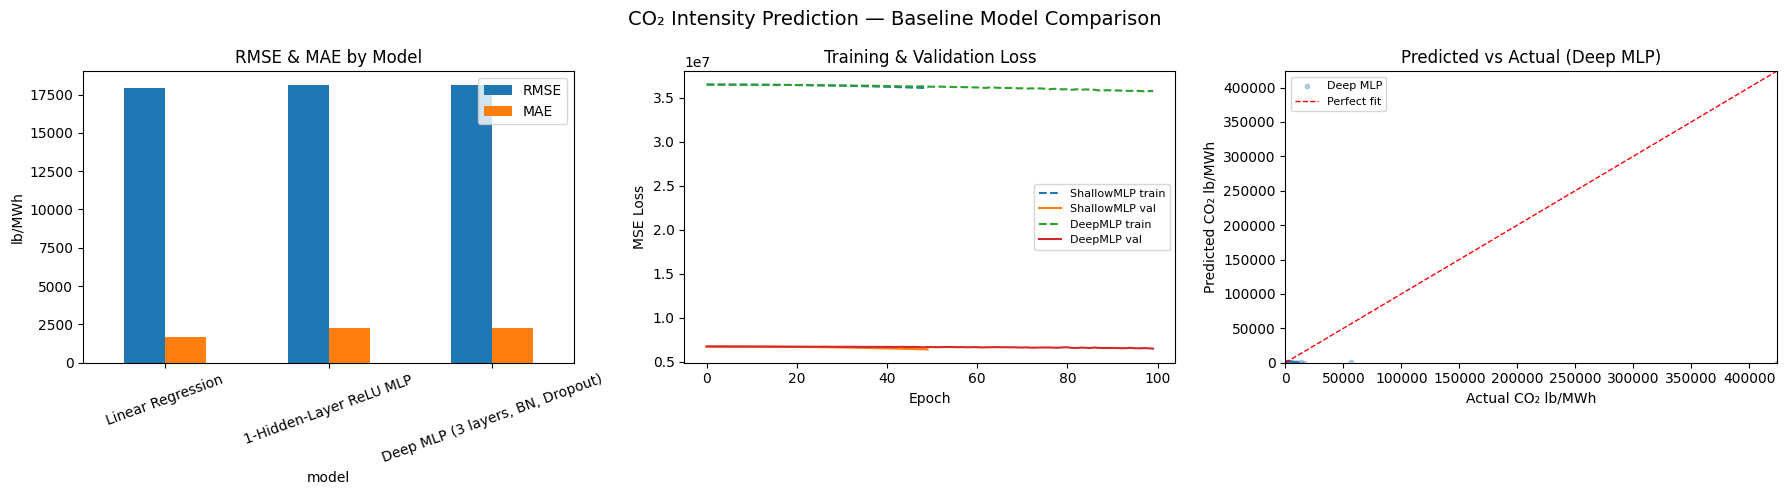


Plot saved to baseline_results.png


In [17]:
# ── 9. Plots ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("CO₂ Intensity Prediction — Baseline Model Comparison", fontsize=14)

# 9a. Metric bar chart
results_df[["RMSE", "MAE"]].plot(kind="bar", ax=axes[0], rot=20)
axes[0].set_title("RMSE & MAE by Model")
axes[0].set_ylabel("lb/MWh")

# 9b. Training curves (neural models)
axes[1].plot(tl_s, label="ShallowMLP train", linestyle="--")
axes[1].plot(vl_s, label="ShallowMLP val")
axes[1].plot(tl_d, label="DeepMLP train",    linestyle="--")
axes[1].plot(vl_d, label="DeepMLP val")
axes[1].set_title("Training & Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend(fontsize=8)

# 9c. Predicted vs Actual (deep model)
axes[2].scatter(y_test, y_pred_deep, alpha=0.3, s=10, label="Deep MLP")
lim = [0, max(y_test.max(), y_pred_deep.max())]
axes[2].plot(lim, lim, "r--", linewidth=1, label="Perfect fit")
axes[2].set_xlim(lim); axes[2].set_ylim(lim)
axes[2].set_title("Predicted vs Actual (Deep MLP)")
axes[2].set_xlabel("Actual CO₂ lb/MWh")
axes[2].set_ylabel("Predicted CO₂ lb/MWh")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("baseline_results.png", dpi=150)
plt.show()
print("\nPlot saved to baseline_results.png")
